# Assignment 6: Applying AI-Based Style Transfer to an Image

## Objective
Compare two AI-based image style-transfer methods on the **same landscape photograph**:

1. **CycleGAN** using a pretrained landscape-to-painting-style model.
2. **VGG19 Neural Style Transfer (NST)** using a selected painting as the style image.

The final result will compare:
- Original landscape
- CycleGAN output
- Neural Style Transfer output

**Important:** This notebook follows the assignment requirement directly. It does **not** use apple-to-orange translation.

## 1. Upload the Input Images

Upload exactly **2 images**:

- **Landscape photo** → the content image used by both methods.
- **Painting/artwork** → the style reference used by VGG19 Neural Style Transfer.

For best results, use a clear landscape photo and a painting with visible brushwork/colors.

In [1]:
from google.colab import files
from PIL import Image
import os

uploaded = files.upload()

image_files = list(uploaded.keys())

if len(image_files) != 2:
    print(f"Warning: {len(image_files)} file(s) uploaded. Please upload exactly 2 images.")
else:
    print("Uploaded:")
    for f in image_files:
        print("-", f)

Saving l.jpg to l.jpg
Saving p.webp to p.webp
Uploaded:
- l.jpg
- p.webp


In [2]:
if len(image_files) < 2:
    raise ValueError("Please upload 2 images: a landscape photo first, then a painting.")

# Upload order: 1st = landscape (content), 2nd = painting (style).
content_path = image_files[0]
style_path = image_files[1]

print("Landscape image:", content_path)
print("Painting image:", style_path)

Landscape image: l.jpg
Painting image: p.webp


## 2. Display the Input Images

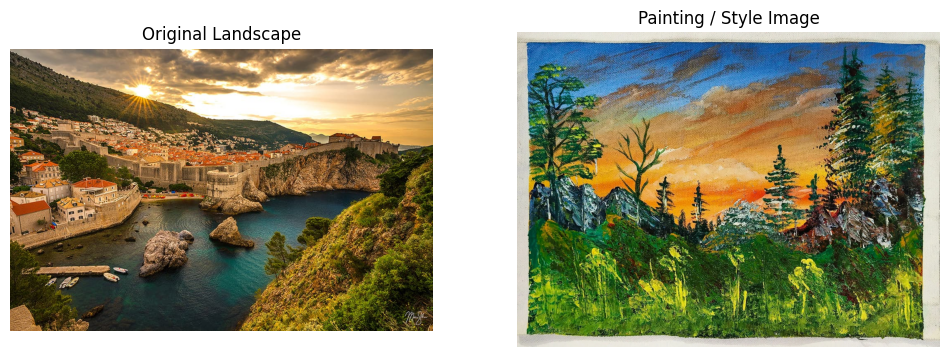

In [3]:
import matplotlib.pyplot as plt

content_img = Image.open(content_path).convert("RGB")
style_img = Image.open(style_path).convert("RGB")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(content_img)
plt.title("Original Landscape")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_img)
plt.title("Painting / Style Image")
plt.axis("off")

plt.show()

## 3. Prepare the CycleGAN Environment

CycleGAN is used here with a **pretrained landscape-photo → painting-style model**. The official CycleGAN model zoo includes pretrained `style_monet`, `style_vangogh`, `style_ukiyoe`, and `style_cezanne` models for landscape photographs.

For this assignment, the pretrained **Monet style** model is used. The uploaded painting is reserved for the separate VGG19 NST method.

In [4]:
import os
import sys
import subprocess

cycle_repo = "/content/pytorch-CycleGAN-and-pix2pix"

if not os.path.exists(cycle_repo):
    subprocess.run([
        "git", "clone", "-q",
        "https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git",
        cycle_repo
    ], check=True)

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "dominate", "visdom"
], check=True)

print("CycleGAN environment ready.")

CycleGAN environment ready.


## 4. Download the Pretrained CycleGAN Model

This uses the repository's model-download script rather than an old hard-coded URL.

In [5]:
model_name = "style_monet"
# NOTE: the repo's download script saves into <repo>/checkpoints, NOT /content/checkpoints.
checkpoints_dir = os.path.join(cycle_repo, "checkpoints")
model_folder = os.path.join(checkpoints_dir, model_name + "_pretrained")
model_file = os.path.join(model_folder, "latest_net_G.pth")

if not os.path.exists(model_file):
    print("Downloading pretrained CycleGAN Monet model...")
    r = subprocess.run(
        ["bash", os.path.join(cycle_repo, "scripts", "download_cyclegan_model.sh"), model_name],
        cwd=cycle_repo, capture_output=True, text=True
    )
    if not os.path.exists(model_file):
        # Fallback: direct download
        import urllib.request
        os.makedirs(model_folder, exist_ok=True)
        url = f"http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/{model_name}.pth"
        print("Script failed, trying direct download:", url)
        urllib.request.urlretrieve(url, model_file)
else:
    print("Pretrained model already exists.")

assert os.path.exists(model_file) and os.path.getsize(model_file) > 1_000_000, \
    "Pretrained model download failed - re-run this cell."
print("Model ready:", model_file)

Model ready: /content/pytorch-CycleGAN-and-pix2pix/checkpoints/style_monet_pretrained/latest_net_G.pth


## 5. Prepare the Landscape for CycleGAN

In [6]:
import shutil

cyclegan_input = "/content/cyclegan_landscape"
testA = os.path.join(cyclegan_input, "testA")
shutil.rmtree(cyclegan_input, ignore_errors=True)   # clear old runs
os.makedirs(testA, exist_ok=True)

# Keep the aspect ratio (long side 512) and make both sides multiples of 4,
# which the CycleGAN generator needs. Avoids squashing the photo to a square.
w, h = content_img.size
scale = 512 / max(w, h)
new_w, new_h = max(4, int(w * scale) // 4 * 4), max(4, int(h * scale) // 4 * 4)
cycle_input_img = content_img.resize((new_w, new_h), Image.LANCZOS)

cycle_input_file = os.path.join(testA, "landscape.jpg")
cycle_input_img.save(cycle_input_file)

print("CycleGAN input prepared:", cycle_input_file, cycle_input_img.size)

CycleGAN input prepared: /content/cyclegan_landscape/testA/landscape.jpg (512, 340)


## 6. Apply CycleGAN

The pretrained model changes the **landscape photo toward a Monet painting style**.

This is the CycleGAN method required for the comparison; it is not an apple-to-orange object translation.

In [7]:
results_dir = "/content/cyclegan_results"
shutil.rmtree(results_dir, ignore_errors=True)
os.makedirs(results_dir, exist_ok=True)

command = [
    sys.executable, os.path.join(cycle_repo, "test.py"),
    "--dataroot", cyclegan_input,
    "--name", "style_monet_pretrained",
    "--model", "test",
    "--dataset_mode", "single",
    "--netG", "resnet_9blocks",
    "--norm", "instance",
    "--no_dropout",
    "--checkpoints_dir", checkpoints_dir,
    "--results_dir", results_dir,
    "--preprocess", "none",          # keep our resized image as-is
    "--input_nc", "3",
    "--output_nc", "3",
    "--batch_size", "1",
    "--num_test", "1",
]
import torch
if not torch.cuda.is_available():
    command += ["--gpu_ids", "-1"]

result = subprocess.run(command, cwd=cycle_repo, capture_output=True, text=True)

if result.returncode != 0:
    print(result.stdout[-2000:])
    print(result.stderr[-3000:])
    raise RuntimeError("CycleGAN test.py failed - see error above.")

print("CycleGAN transformation completed!")

CycleGAN transformation completed!


## 7. Load and Display the CycleGAN Output

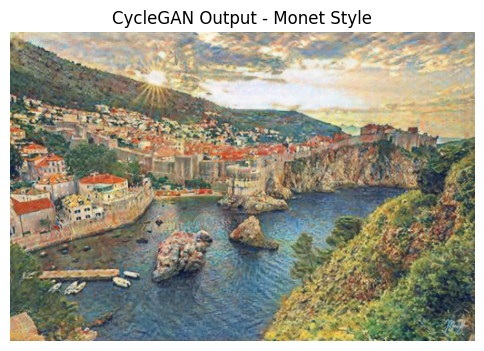

Output: /content/cyclegan_results/style_monet_pretrained/test_latest/images/landscape_fake.png


In [8]:
from pathlib import Path

fake_outputs = list(Path(results_dir).rglob("*_fake*.png"))
if not fake_outputs:
    raise FileNotFoundError(
        f"No CycleGAN output found under {results_dir}. Files present: "
        f"{[str(p) for p in Path(results_dir).rglob('*.png')]}"
    )

cyclegan_output_path = str(fake_outputs[0])
cyclegan_img = Image.open(cyclegan_output_path).convert("RGB")

plt.figure(figsize=(6, 5))
plt.imshow(cyclegan_img)
plt.title("CycleGAN Output - Monet Style")
plt.axis("off")
plt.show()

print("Output:", cyclegan_output_path)

## 8. Cycle Consistency

CycleGAN is based on **cycle consistency**.

Conceptually:

**Landscape → Monet-style image → Landscape reconstruction**

The reconstruction is encouraged to remain similar to the original image. This helps the model learn an unpaired mapping between the two image domains without requiring matching landscape/painting pairs.

# Method 2: VGG19 Neural Style Transfer

The second method uses:
- The **same landscape** as the content image.
- The **uploaded painting** as the style image.
- VGG19 features to preserve content and transfer visual style.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 9. Load VGG19

In [10]:
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

# In-place ReLUs overwrite the stored feature maps and can break autograd,
# so switch them to normal ReLUs.
for layer in vgg:
    if isinstance(layer, nn.ReLU):
        layer.inplace = False

for parameter in vgg.parameters():
    parameter.requires_grad = False

print("VGG19 loaded.")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 161MB/s]


VGG19 loaded.


## 10. Preprocess the Content and Style Images

In [11]:
image_size = 512 if device.type == "cuda" else 256   # long side

# Keep the landscape's aspect ratio (no squashing); resize the painting to match.
w, h = content_img.size
scale = image_size / max(w, h)
size_hw = (int(h * scale), int(w * scale))

transform = transforms.Compose([
    transforms.Resize(size_hw),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

content_tensor = transform(content_img).unsqueeze(0).to(device)
style_tensor = transform(style_img).unsqueeze(0).to(device)

print("Content tensor:", content_tensor.shape)
print("Style tensor:", style_tensor.shape)

Content tensor: torch.Size([1, 3, 341, 512])
Style tensor: torch.Size([1, 3, 341, 512])


## 11. Select VGG19 Layers

The selected deeper layer represents content information, while several layers capture style information.

In [12]:
# conv4_2 (index 21) = content; conv1_1, 2_1, 3_1, 4_1, 5_1 = style
content_layers = ["21"]
style_layers = ["0", "5", "10", "19", "28"]
selected_layers = set(content_layers + style_layers)
print("Content layer:", content_layers, "| Style layers:", style_layers)

Content layer: ['21'] | Style layers: ['0', '5', '10', '19', '28']


## 12. Gram Matrix for Style Features

In [13]:
def gram_matrix(tensor):
    batch, channels, height, width = tensor.size()
    features = tensor.view(channels, height * width)
    gram = torch.mm(features, features.t())
    return gram / (channels * height * width)

def get_features(image):
    result = {}
    x = image

    for name, layer in vgg._modules.items():
        x = layer(x)
        if name in selected_layers:
            result[name] = x

    return result

content_features = get_features(content_tensor)
style_features = get_features(style_tensor)

style_grams = {
    layer: gram_matrix(style_features[layer])
    for layer in style_layers
}

print("Content and style features extracted.")

Content and style features extracted.


## 13. Optimize the Styled Image

In [14]:
target = content_tensor.clone().requires_grad_(True)

style_weight = 1e6
content_weight = 1.0
steps = 300

optimizer = optim.Adam([target], lr=0.02)

for step in range(steps):
    target_features = get_features(target)

    content_loss = torch.mean(
        (target_features[content_layers[0]] - content_features[content_layers[0]]) ** 2
    )

    style_loss = 0
    for layer in style_layers:
        target_gram = gram_matrix(target_features[layer])
        style_loss += torch.mean((target_gram - style_grams[layer]) ** 2)

    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if (step + 1) % 50 == 0:
        print(f"Step {step + 1}/{steps} | Content: {content_loss.item():.4f} | Style: {style_loss.item():.4f}")

print("Neural Style Transfer completed.")

Step 50/300 | Content: 46.9678 | Style: 0.0004
Step 100/300 | Content: 46.6610 | Style: 0.0002
Step 150/300 | Content: 45.1397 | Style: 0.0001
Step 200/300 | Content: 43.7896 | Style: 0.0001
Step 250/300 | Content: 42.6288 | Style: 0.0001
Step 300/300 | Content: 41.7385 | Style: 0.0001
Neural Style Transfer completed.


## 14. Display the NST Output

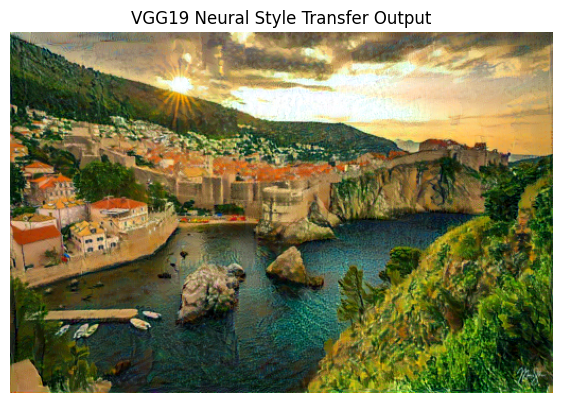

In [15]:
def tensor_to_image(tensor):
    image = tensor.detach().cpu().squeeze(0)
    image = image * torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)
    image = image + torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)
    image = torch.clamp(image, 0, 1)
    return image.permute(1, 2, 0).numpy()

nst_result = tensor_to_image(target)

plt.figure(figsize=(7, 5))
plt.imshow(nst_result)
plt.title("VGG19 Neural Style Transfer Output")
plt.axis("off")
plt.show()

# 15. Final Side-by-Side Comparison

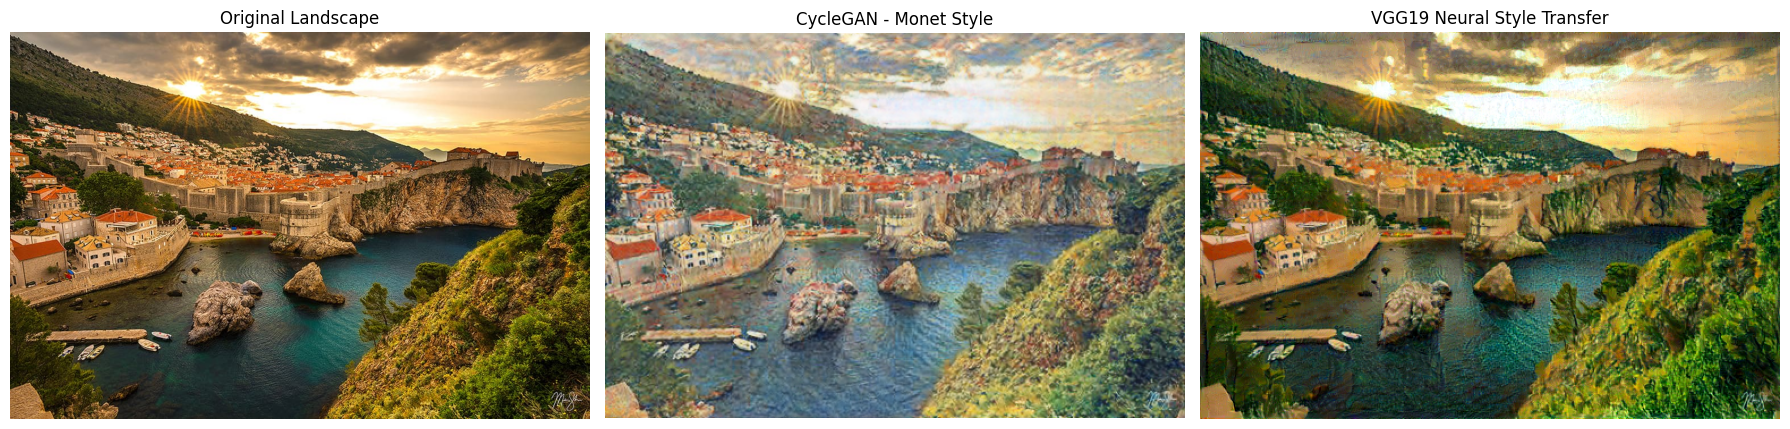

Final comparison saved to: /content/final_style_transfer_comparison.png


In [16]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(content_img)
plt.title("Original Landscape")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cyclegan_img)
plt.title("CycleGAN - Monet Style")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(nst_result)
plt.title("VGG19 Neural Style Transfer")
plt.axis("off")

plt.tight_layout()

final_path = "/content/final_style_transfer_comparison.png"
plt.savefig(final_path, dpi=200, bbox_inches="tight")
plt.show()

print("Final comparison saved to:", final_path)

# 16. Written Comparison

**Content preservation:** Neural Style Transfer kept the original structure of the landscape more directly, because its loss function explicitly matches the content features of the photo. CycleGAN's output is a learned "Monet-like" version, so fine details can be softened or altered.

**Stronger style transformation:** CycleGAN gave a more uniform, painting-like change across the whole image (colour palette and tone), because it was trained to map photos into a whole painting domain. NST copied the colour and brushstroke texture of the specific painting I supplied, so its look depends heavily on that reference image.

**Differences noticed:** CycleGAN is fast (one forward pass) but limited to the style it was trained on; NST is slower (iterative optimisation per image) but works with any painting.




# 17. Conclusion

Both methods demonstrate AI-based style transfer, but they work differently. CycleGAN performs a learned domain-level transformation using a pretrained landscape-to-painting model, while VGG19 Neural Style Transfer combines the content of the landscape with the style features of the selected painting. The side-by-side comparison shows how the two approaches balance content preservation and style transformation differently.